# priya_loader — a quick start

If you know the Lyman-α forest as a cosmological probe but have never run a
hydrodynamic simulation, this notebook is written for you. The
[PRIYA](https://arxiv.org/abs/2306.05471) suite is a grid of MP-Gadget simulations
built to predict forest statistics across cosmology and IGM thermal history;
`priya_loader` hands those simulations to you as plain `numpy` arrays, so that you
can treat the whole suite as a *dataset* and never have to touch the simulation code
itself.

Two products travel together out of each simulation, and they are the two halves of
a forest-bias measurement:

- the **initial linear density field** `δ₁` — the very field your bias is defined
  against, written at the simulation's starting redshift `z≈99`; and
- the **Lyman-α optical depth** `τ` at each output redshift — the forest itself, on a
  3-D grid of skewers, from which the transmitted flux is `F = exp(−τ)`.

The headline object, `PriyaDataset`, walks every `(simulation, redshift)` pair and
hands back exactly the tuple a downstream (e.g. JAX) pipeline wants:

    Sample(params, redshift, δ₁, τ)         # .as_tuple() for the bare 4-tuple

Everything below runs on the real, staged suite. We have set it to default to the
NERSC path; point `$PRIYA_ROOT` (or edit the `ROOT` cell) at your own copy to run it
elsewhere — no path is hard-coded.

> **A note on provenance.** Simulations carry a great deal of silent convention — unit
> systems, what exactly the "IC density" block holds, which axis of the τ grid is the
> line of sight. Where this notebook leans on one, we name its source in passing and
> pin it to an exact upstream git commit and line in
> [`PROVENANCE.md`](../PROVENANCE.md).

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import priya_loader as pl
from priya_loader import (
    discover_simulations, SimParams, load_tau_grid,
    load_ic_density, PriyaDataset, units,
)

# Defaults to the staged NERSC PRIYA low-res suite; override with $PRIYA_ROOT.
ROOT = os.environ.get(
    "PRIYA_ROOT",
    "/global/cfs/cdirs/desicollab/users/jibancat/priya/emu_full",
)
print("priya_loader", pl.__version__, "| ROOT:", ROOT)
print("ROOT exists:", Path(ROOT).is_dir())

priya_loader 0.2.0.dev0 | ROOT: /global/cfs/cdirs/desicollab/users/jibancat/priya/emu_full
ROOT exists: True


## 1. The simulations, and the nine numbers that label them

Each PRIYA simulation is one model universe: a choice of cosmology together with a
choice of IGM thermal history. The suite samples **nine parameters** on a Latin
hypercube, and it is worth pausing on what they are, because they are precisely the
*labels* you will attach to every flux field you pull out. Four of them set the
background cosmology and the underlying matter clustering; the other five set the
heating and ionization state of the gas — the part of the model the forest is so
directly sensitive to.

| group | parameter | folder key | what it controls | prior range |
|---|---|---|---|---|
| cosmology | `n_s` | `ns` | primordial scalar spectral index | 0.80 – 1.05 |
| | `A_p` | `Ap` | primordial amplitude at the **8 Mpc/h** scale (`k = 2π/8 ≈ 0.785 h/Mpc`) — the scale the forest pins down | 1.2 – 2.6 ×10⁻⁹ |
| | `Ω_m h²` | `omegamh2` | physical total-matter density | 0.14 – 0.146 |
| | `h` | `hub` | Hubble parameter (prior-dominated) | 0.65 – 0.75 |
| He II reionization | `z_HeII,i` | `herei` | redshift at which He II reionization **begins** | 3.5 – 4.1 |
| | `z_HeII,f` | `heref` | redshift at which it **ends** | 2.6 – 3.2 |
| | `α_q` | `alphaq` | the quasar (He II–ionizing) spectral index during He II reionization — harder spectra heat the gas more | 1.3 – 2.5 |
| H I reionization | `z_HI` | `hireionz` | median redshift of hydrogen reionization | 6.5 – 8.0 |
| feedback | `ε_AGN` | `bhfeedback` | thermal efficiency of black-hole (AGN) feedback | 0.03 – 0.07 |

(Two further nuisances — the mean optical depth `τ₀` and its redshift slope — are
applied in post-processing, not built into the simulations, so they are not in this
list.) The folder name is simply these nine numbers concatenated in a fixed on-disk
order (which differs from the physics grouping above), which is why it reads the way
it does; `priya_loader` decodes it (following `lya_emulator`; see
`PROVENANCE.md`) and, for the box and particle count, trusts the authoritative run
configuration over the often-stale `SimulationICs.json`.

Let us read the whole suite, print the nine labels of one simulation, and then look
at a single 2-D shadow of that 9-D design — the `n_s`–`A_p` plane, the two parameters
the forest amplitude and tilt constrain most directly.

discovered 60 simulations

one simulation, by its nine labels:
    ns           = 0.803
    Ap           = 2.2e-09
    omegamh2     = 0.141
    hub          = 0.735
    herei        = 4.05
    heref        = 2.67
    alphaq       = 2.21
    hireionz     = 7.17
    bhfeedback   = 0.056

  box = 120.0 Mpc/h,  npart = 1536  (lowres),  z: 99.0 -> 2.0



parameters read for 60 / 60 sims


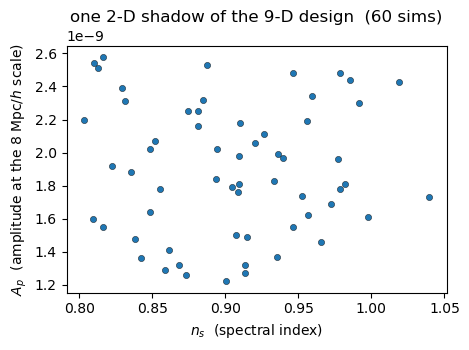

In [2]:
sims = discover_simulations(ROOT)
print("discovered", len(sims), "simulations\n")

p0 = SimParams.from_dir(sims[0].directory)
print("one simulation, by its nine labels:")
for key in ("ns", "Ap", "omegamh2", "hub", "herei", "heref", "alphaq", "hireionz", "bhfeedback"):
    print(f"    {key:12s} = {p0.name_params[key]}")
print(f"\n  box = {p0.box} Mpc/h,  npart = {p0.npart}  ({p0.fidelity}),"
      f"  z: {p0.z_init} -> {p0.z_end}")

# A_p is the folder-name amplitude at PRIYA's k = 2*pi/8 ~ 0.78/Mpc pivot, NOT
# scalar_amp (= A_s at k=0.05); they differ by ((2pi/8)/0.05)**(ns-1).
ns, Ap = [], []
for s in sims:
    try:
        p = SimParams.from_dir(s.directory)
        ns.append(p.ns); Ap.append(float(p.name_params["Ap"]))
    except Exception:
        pass
print("\nparameters read for", len(ns), "/", len(sims), "sims")

plt.figure(figsize=(4.8, 3.6))
plt.scatter(ns, Ap, s=20, c="C0", edgecolors="k", linewidths=0.3)
plt.xlabel(r"$n_s$  (spectral index)")
plt.ylabel(r"$A_p$  (amplitude at the 8 Mpc/$h$ scale)")
plt.title(f"one 2-D shadow of the 9-D design  ({len(ns)} sims)")
plt.tight_layout(); plt.show()

## 2. The forest: optical depth `τ`, and flux `F = exp(−τ)`

This is the quantity you actually measure. `load_tau_grid(path, axis)` returns the
raw `τ` for one line-of-sight axis as a `(ngrid, ngrid, nbins)` cube — two transverse
indices and one line-of-sight index — exactly as `fake_spectra` wrote it, never
rebinned. It lives in **redshift space**: the line-of-sight axis is a velocity axis,
so the field already carries the peculiar-velocity distortions (the same `β_F` you
know from 3-D forest analyses). Reading it needs only `h5py`.

`F = exp(−τ)` is the transmitted flux — dark where `τ` is large (the dense filaments
that absorb the light) and bright in the voids. Below: a transverse slice of `τ`, the
same slice of `F`, and a handful of `τ` skewers down the line of sight.

tau cube : (480, 480, 1556)  (ngrid, ngrid, nbins)
redshift : 5.4   box: 120.0 Mpc/h


cube_axes: ('x', 'y', 'z')    <F> (whole cube): 0.095


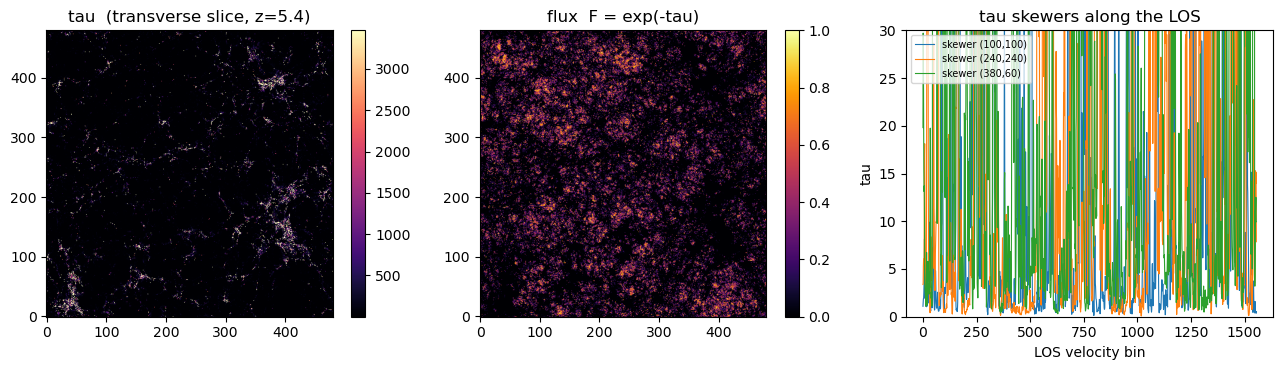

In [3]:
sim = sims[0]
spec = sorted((Path(ROOT) / sim.directory.name / "output").glob("SPECTRA_*"))[0]
fpath = spec / "lya_forest_spectra_grid_480.hdf5"

g = load_tau_grid(fpath, axis=3)        # axis 3: cube_axes = (x, y, z), LOS = z
print("tau cube :", g.tau.shape, " (ngrid, ngrid, nbins)")
print("redshift :", g.redshift, "  box:", g.box, "Mpc/h")
print("cube_axes:", g.cube_axes, "   <F> (whole cube):", round(float(np.exp(-g.tau).mean()), 3))

b = g.nbins // 2
tau_sl  = g.tau[:, :, b]
flux_sl = np.exp(-tau_sl)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
im0 = ax[0].imshow(tau_sl, origin="lower", cmap="magma", vmax=np.percentile(tau_sl, 99))
ax[0].set_title(f"tau  (transverse slice, z={g.redshift})"); fig.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(flux_sl, origin="lower", cmap="inferno", vmin=0, vmax=1)
ax[1].set_title("flux  F = exp(-tau)"); fig.colorbar(im1, ax=ax[1])
for (i, j) in [(100, 100), (240, 240), (380, 60)]:
    ax[2].plot(g.tau[i, j, :], lw=0.8, label=f"skewer ({i},{j})")
ax[2].set_title("tau skewers along the LOS"); ax[2].set_xlabel("LOS velocity bin")
ax[2].set_ylabel("tau"); ax[2].set_ylim(0, 30); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.show()
del g, tau_sl, flux_sl

### Three lines of sight in one file

`fake_spectra` shoots skewers along **all three box axes** — `ngrid²` of them per
axis, `3·ngrid²` in all — so a single output already holds three different views of
the same box (three projections of one density realization, not independent skies).
You choose one with the `axis` argument. The only
subtlety is bookkeeping: because the line-of-sight coordinate is dropped, *which* of
the two remaining cube indices is "x" and which is "y" depends on the axis you asked
for. The loader keeps that mapping for you in `cube_axes`:

| `axis=` | line of sight | `cube_axes`  (two transverse coords, then LOS) |
|:--:|:--:|:--:|
| 1 | x | (y, z, x) |
| 2 | y | (x, z, y) |
| 3 | z | (x, y, z) |

So a skewer is just `g.tau[i, j, :]` — but for `axis=3` the pair `(i, j)` means
`(x, y)` looking down `z`, whereas for `axis=1` the *same* `(i, j)` means `(y, z)`
looking down `x`. The two cells below make that concrete: first the mean-flux map of
each axis (three shadows of one cosmic web), then the *same* cube cell `(120, 200)`
read out as a sightline on each axis — three different spectra, as it should be.

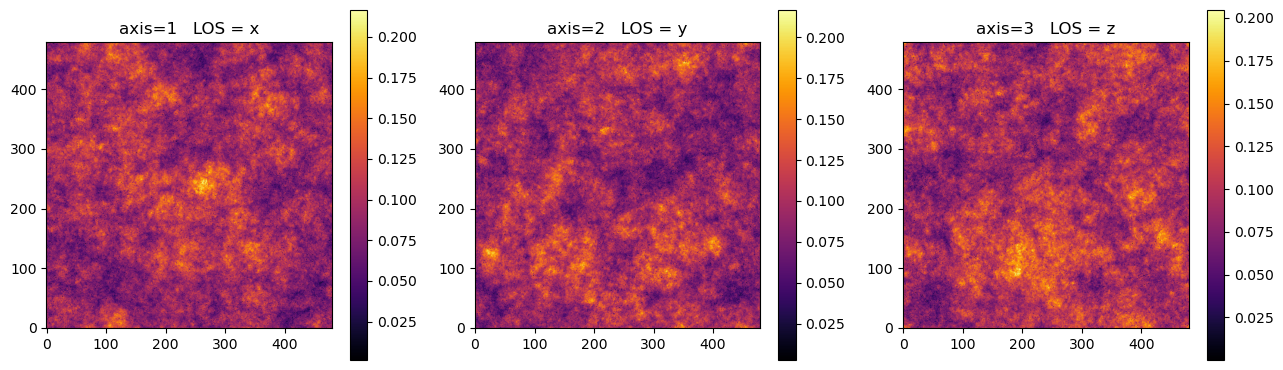

In [4]:
# mean-flux map down each of the three line-of-sight axes (loaded one at a time)
skewers = {}
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
for n, axis in enumerate((1, 2, 3)):
    ga = load_tau_grid(fpath, axis=axis)
    mf = np.exp(-ga.tau).mean(axis=2)                  # average F down this axis' LOS
    skewers[axis] = (ga.tau[120, 200, :].copy(), tuple(ga.cube_axes))
    im = ax[n].imshow(mf, origin="lower", cmap="inferno")
    ax[n].set_title(f"axis={axis}   LOS = {'xyz'[axis - 1]}")
    fig.colorbar(im, ax=ax[n])
    del ga
plt.tight_layout(); plt.show()

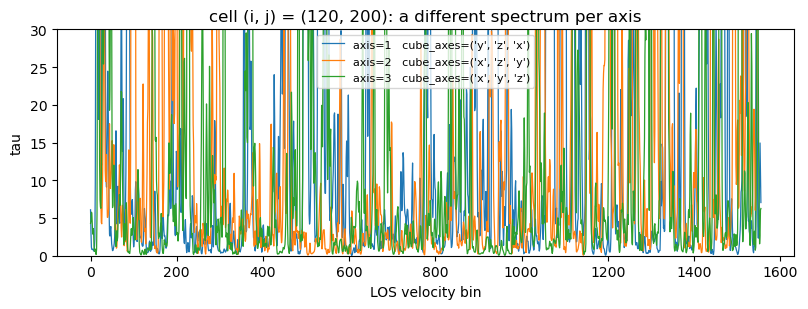

In [5]:
# the SAME cube cell (120, 200) is a different sightline on each axis
plt.figure(figsize=(8.2, 3.2))
for axis in (1, 2, 3):
    tau_skewer, ca = skewers[axis]
    plt.plot(tau_skewer, lw=0.9, label=f"axis={axis}   cube_axes={ca}")
plt.title("cell (i, j) = (120, 200): a different spectrum per axis")
plt.xlabel("LOS velocity bin"); plt.ylabel("tau"); plt.ylim(0, 30); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()
del skewers

### A sanity check: mean flux falls with redshift

One quick check that `τ` is physical: the high-redshift universe is denser and more
neutral, so it absorbs more, and the mean transmitted flux `⟨F⟩` should fall steadily
with redshift — from `~0.8` near `z≈2.4` toward `~0.1` by `z≈5.4`. We recover exactly
that shape below; it tracks the observed mean-flux evolution (Faucher-Giguère et al.
2008, [arXiv:0709.2382](https://arxiv.org/abs/0709.2382); Becker et al. 2013,
[arXiv:1208.2584](https://arxiv.org/abs/1208.2584)) in **shape and sign**, though not
in absolute level — the simulation's UV background is not tuned to the observed `⟨F⟩`,
which is what the `τ₀` nuisance is for.

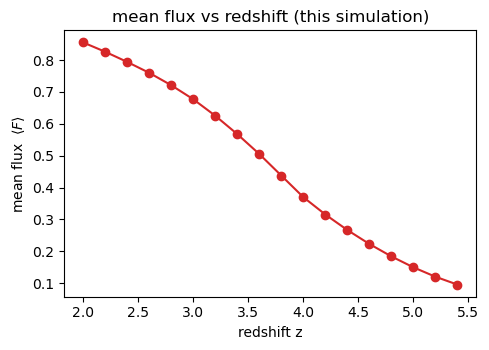

monotonic decreasing with z: True


In [6]:
specs = sorted((Path(ROOT) / sim.directory.name / "output").glob("SPECTRA_*"))
zs, mfs = [], []
for s in specs:
    f = s / "lya_forest_spectra_grid_480.hdf5"
    if not f.exists():
        continue
    gg = load_tau_grid(f, axis=3)
    zs.append(gg.redshift); mfs.append(float(np.exp(-gg.tau).mean()))
zs, mfs = np.array(zs), np.array(mfs)
o = np.argsort(zs)

plt.figure(figsize=(5.0, 3.6))
plt.plot(zs[o], mfs[o], "o-", c="C3")
plt.xlabel("redshift z"); plt.ylabel(r"mean flux  $\langle F\rangle$")
plt.title("mean flux vs redshift (this simulation)")
plt.tight_layout(); plt.show()
print("monotonic decreasing with z:", bool(np.all(np.diff(mfs[o]) <= 1e-6)))

## 3. The initial conditions: the linear field vs. the Zel'dovich particles

Here is the point that most often trips people up, so it is worth being careful with.
The IC file at `z≈99` actually gives you **two different density fields** — one
written out directly, one you build from the particles — and which you want depends on
what you are doing.

When MP-GenIC (the suite's initial-conditions generator) builds the initial
conditions, it lays particles on a regular grid and moves each one by the
**Zel'dovich approximation** — first-order Lagrangian perturbation theory,
`x = q + Ψ(q)`, with `q` the grid position and `Ψ` the linear displacement. The
particle distribution you end up with is therefore the *Zel'dovich-evolved* field,
already a (mildly) non-linear realization. Cloud-in-cell painting those particles
(spreading each particle's mass over the eight grid cells it straddles) — what
`field="cic"` does — gives you that Eulerian Zel'dovich density.

Separately, MP-GenIC writes an **`ICDensity` block**: the **pure linear overdensity
`δ₁`** (white noise × the linear transfer function) evaluated on the Lagrangian grid,
*before* any displacement. That is what `field="icdensity"` reads, with no painting at
all — and it is the field that linear theory, and therefore your flux-bias definition,
actually refers to.

| `field=` | what it is | how it is built | use it for |
|---|---|---|---|
| `"icdensity"` | the linear field `δ₁` | read straight from the `ICDensity` block (no painting) | the bias cross-spectrum reference |
| `"cic"` | the Zel'dovich (Eulerian) density | CIC-paint the 1LPT-displaced particles | a quick density view; rolling your own mesh |

At `z≈99` the displacements are tiny — far smaller than a grid cell — so the two
fields *look* almost identical, and that near-equality is itself a useful check (we
make it below). But they are not the same object: for a clean linear cross-spectrum
you want `δ₁`, not the CIC field. (`nmesh` should divide `ngrid` for the `icdensity`
route — otherwise the loader warns and the block-average is uneven; this sim's
production ICs are `1536³`, but what is staged here is the lighter `512³` companion,
so we use `nmesh=256`.)

IC dir: /global/cfs/cdirs/desicollab/users/jibancat/priya/emu_full/ns0.803Ap2.2e-09herei4.05heref2.67alphaq2.21hub0.735omegamh20.141hireionz7.17bhfeedback0.056/ICS/120_512_99 
exists: True



linear delta_1 : (256, 256, 256)  mean -1.52e-06  std 0.055
Zel'dovich CIC : (256, 256, 256)  mean 0.00e+00  std 0.050


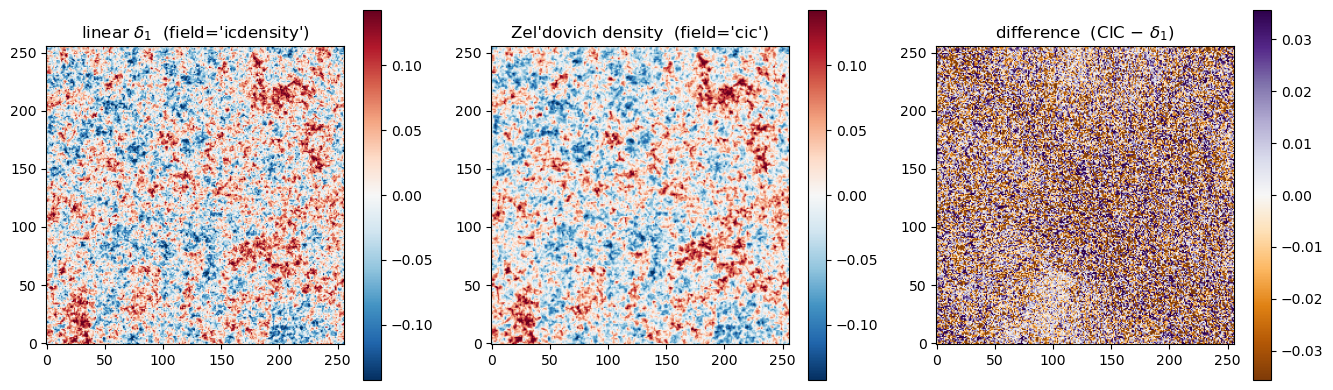

In [7]:
ICDIR = Path(ROOT) / sim.directory.name / "ICS" / "120_512_99"   # the 512^3 companion (production ICs are 1536^3)
print("IC dir:", ICDIR, "\nexists:", ICDIR.is_dir())

lin = load_ic_density(ICDIR, ptype="dm", nmesh=256, field="icdensity")  # linear delta_1
cic = load_ic_density(ICDIR, ptype="dm", nmesh=256, field="cic")        # Zel'dovich (CIC)

print("\nlinear delta_1 :", lin.delta.shape, " mean %.2e  std %.3f" % (lin.delta.mean(), lin.delta.std()))
print("Zel'dovich CIC :", cic.delta.shape, " mean %.2e  std %.3f" % (cic.delta.mean(), cic.delta.std()))

k = lin.delta.shape[2] // 2
v = float(np.percentile(np.abs(lin.delta), 99))          # shared symmetric scale
diff = cic.delta[:, :, k] - lin.delta[:, :, k]
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.0))
im0 = ax[0].imshow(lin.delta[:, :, k], origin="lower", cmap="RdBu_r", vmin=-v, vmax=v)
ax[0].set_title(r"linear $\delta_1$  (field='icdensity')"); fig.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(cic.delta[:, :, k], origin="lower", cmap="RdBu_r", vmin=-v, vmax=v)
ax[1].set_title("Zel'dovich density  (field='cic')"); fig.colorbar(im1, ax=ax[1])
im2 = ax[2].imshow(diff, origin="lower", cmap="PuOr", vmin=-v / 4, vmax=v / 4)
ax[2].set_title(r"difference  (CIC $-\ \delta_1$)"); fig.colorbar(im2, ax=ax[2])
plt.tight_layout(); plt.show()

The first two panels are, to the eye, the same cosmic web — exactly as expected
when the displacements are sub-cell. The third panel is their *difference*, on a 4×
tighter color scale: small, but real and structured. Two things contribute to it — the
density imprint of the Zel'dovich displacement (the particles have shifted slightly off
their grid points), and the fact that the two fields are smoothed differently here (the
CIC paint carries a `sinc²` window, while reading `δ₁` at `nmesh=256 < ngrid=512`
block-averages it into a `sinc` top-hat). So read this residual as "close, but not
identical" — not as the displacement field itself (that is a *vector*, `Ψ`; this is a
scalar density difference). The real test of the IC reader is the **correlation**
between the two fields: a transpose or an off-by-one in the Lagrangian index decode
would destroy it, and it does not.

In [8]:
a = (lin.delta - lin.delta.mean()).ravel()
b = (cic.delta - cic.delta.mean()).ravel()
r = float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))
print("linear delta_1  <->  Zel'dovich CIC  correlation at z~99:  r = %.4f" % r)

linear delta_1  <->  Zel'dovich CIC  correlation at z~99:  r = 0.8674


## 4. `PriyaDataset`: the whole suite as one loop

Everything above was one simulation and one redshift, reached by hand. `PriyaDataset`
does the bookkeeping: iterate it and it yields `Sample(params, redshift, ic, tau)`
lazily, one `(simulation, redshift)` at a time, so the whole suite streams through
without ever sitting in memory at once. It is forgiving of partial data — a
simulation with no staged `τ` is skipped, and a missing IC simply comes back as
`ic=None` rather than an error.

> **Which IC does it load?** By default `PriyaDataset` asks for the
> **production-resolution** IC (`1536³` low-res / `3072³` hi-res — Bird et al. 2023,
> [arXiv:2306.05471](https://arxiv.org/abs/2306.05471)), read from the run config. On
> the staging used here only the `512³` companion is present, so `s.ic` comes back as
> `None` below. Until the production IC is transferred, reach for the linear field the
> way we did in §3 — `load_ic_density(.../ICS/120_512_99, …)`.

When you are ready to write the dataset to disk, `ds.export(outdir)` drops one
self-describing `.npz` per `(simulation, redshift)`; we don't call it here, since it
writes files, but that single line is what turns the suite into an ML-ready dataset.

In [9]:
import warnings
ds = PriyaDataset(ROOT, ic_nmesh=256, ic_field="icdensity", flux_axis=3)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    s = next(iter(ds))                       # first (sim, z)
print("Sample:")
print("  params  :", s.params.name[:48], "...")
print("  redshift:", s.redshift)
print("  ic      :", None if s.ic is None else s.ic.shape, "(linear delta_1)")
print("  tau     :", None if s.tau is None else s.tau.shape)
print("  as_tuple length:", len(s.as_tuple()), " -> [params, z, ic, tau]")
del s

Sample:
  params  : ns0.803Ap2.2e-09herei4.05heref2.67alphaq2.21hub0 ...
  redshift: 5.4
  ic      : None (linear delta_1)
  tau     : (480, 480, 1556)
  as_tuple length: 4  -> [params, z, ic, tau]


## 5. From here, the bias is yours

The loader stops, deliberately, at *loading*. Turning `δ₁` and `τ` into a flux bias is
the science. The estimator de Belsunce et al. 2025
([arXiv:2507.00284](https://arxiv.org/abs/2507.00284), Eq. 5) use is the field-level
transfer function `β₁(k,μ) = ⟨δ_F δ₁*⟩ / ⟨|δ₁|²⟩`, where `δ_F = F/⟨F⟩ − 1` is the flux
**contrast** (not the raw flux `F` — they differ by `⟨F⟩`); the flux bias `b_F` is the
large-scale (`k → 0`) limit of `β₁`. They validated this on the Sherwood suite at
`z=2.8`; `priya_loader` is what brings the same estimator to PRIYA, across redshift and
the nine parameters — the follow-up this package exists for.

The choices that estimator asks for are yours to make: growth-rescaling `δ₁` from
`z≈99` to the flux redshift, co-registering the cubes (recall the `τ` axes are permuted
— `cube_axes` again), deconvolving the mass-assignment window (CIC `sinc²` for
`field="cic"`, or the block-average `sinc` if you read `δ₁` below `ngrid`), and settling
the mean-flux normalization and the DLA treatment. What this package promises is the
piece that is easy to get *silently* wrong: that the `δ₁` and the `τ` it gives you share
a box, an origin, and an orientation, so the cross-spectrum is meaningful once you have
done the rest.

The full recipe — estimator, growth rescaling, window, co-registration, the
`(b_F, β_F)` decomposition — is written up in [`HANDOFF.md`](../HANDOFF.md).

## 6. Recap

With no MP-Gadget expertise, and entirely on the real PRIYA suite, you have:

- **§1** read the nine parameters that label each simulation, and seen the design grid;
- **§2** loaded the raw `τ` cube and flux `F = exp(−τ)`, read skewers along all three
  line-of-sight axes, and confirmed `⟨F⟩(z)` falls as it should;
- **§3** loaded the IC density two ways — the linear `δ₁` (`icdensity`) and the
  Zel'dovich particles (`cic`) — and seen exactly how and why they differ;
- **§4** streamed the whole suite through `PriyaDataset` as `[params, z, δ₁, τ]` —
  here `δ₁` comes back `None` until the `1536³` IC is staged, so §3 read the `512³`
  field directly.

**To go further:** `ds.export("<scratch>/priya_npz")` to materialize the dataset, or
[`HANDOFF.md`](../HANDOFF.md) for the bias recipe. To run anywhere else, change only
`ROOT` / `$PRIYA_ROOT`. Every convention used above is pinned to its upstream source
in [`PROVENANCE.md`](../PROVENANCE.md).